In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

1. Загрузите датасет breast_cancer из библиотеки sklearn.

In [2]:
data = load_breast_cancer()
X = data.data[:,:2]
y = data.target
df = pd.DataFrame(data.data[:,:2], columns=data.feature_names[:2])
df['target'] = data.target
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

2. Выведите в виде гистограммы распределения непрерывных атрибутов в этом наборе данных.

<Axes: xlabel='mean radius', ylabel='mean texture'>

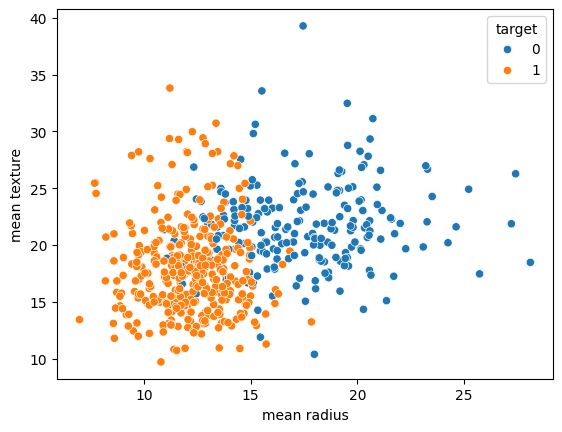

In [3]:
sns.scatterplot(x=df['mean radius'], y=df['mean texture'], hue=df['target'])

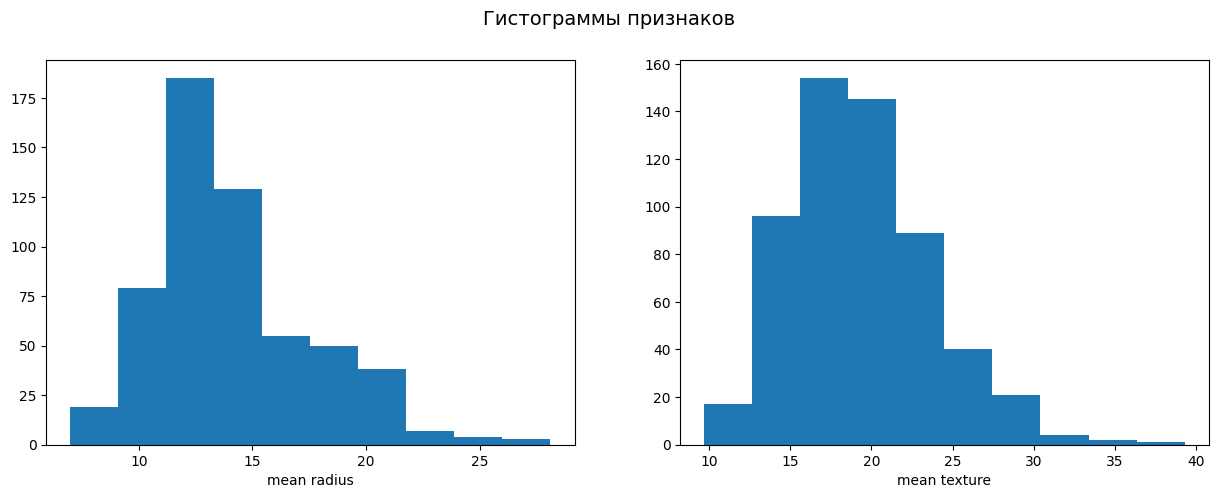

In [4]:
plt.figure(figsize=(15, 5))
for i in range(2):    
    plt.subplot(1, 2, i+1)
    plt.hist(X[:, i])
    plt.xlabel(data.feature_names[i])
plt.suptitle('Гистограммы признаков',fontsize=14)
plt.show()

3. Постройте модель наивного байесовского классификатора на первых двух столбцах и оцените ее качество.

In [5]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
gaussian_nb = GaussianNB()
gaussian_nb.fit(X, y)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [6]:
y_pred = gaussian_nb.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[164  48]
 [ 17 340]]
Accuracy=  0.8857644991212654
F1_score=  0.912751677852349


4. Постройте ту же модель на полном датасете и сравните ее качество с первой.

In [7]:
X = data.data
y = data.target
X.shape, y.shape

((569, 30), (569,))

In [8]:
gaussian_nb.fit(X, y)
y_pred = gaussian_nb.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[189  23]
 [ 10 347]]
Accuracy=  0.9420035149384886
F1_score=  0.9546079779917469


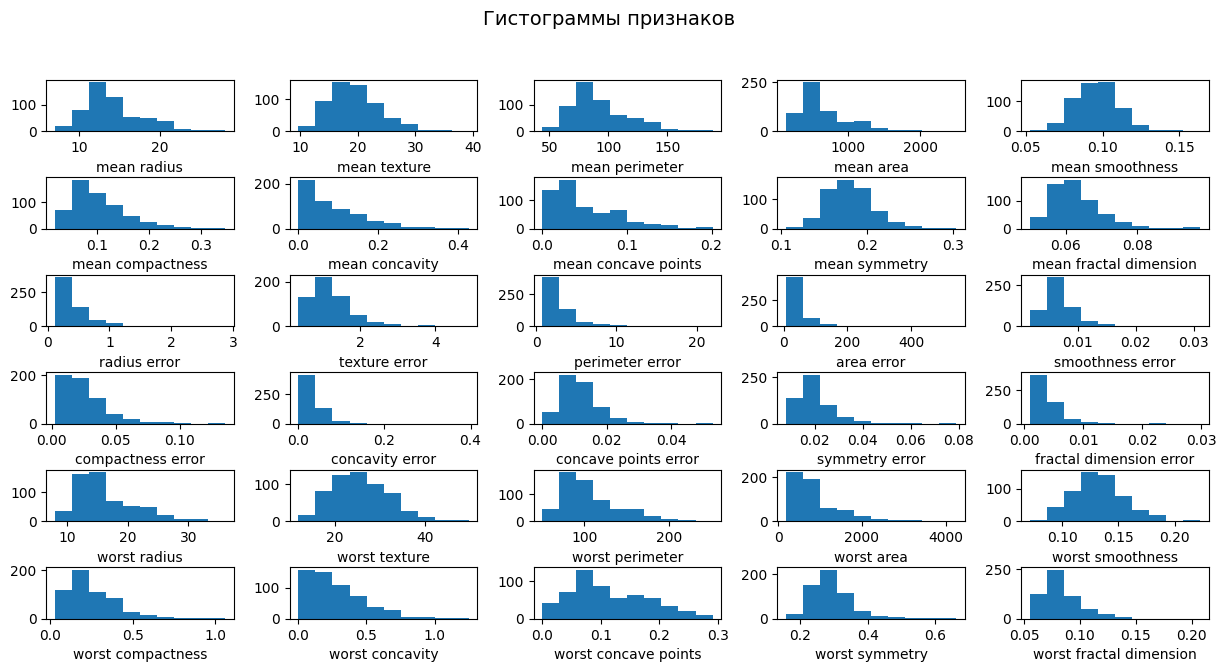

In [9]:
f = plt.figure(figsize=(15, 7))
for i in range(30):
    plt.subplot(6, 5, i+1)
    plt.hist(X[:, i])
    
    plt.xlabel(data.feature_names[i])
f.subplots_adjust(hspace=0.9,wspace=0.3)    
plt.suptitle('Гистограммы признаков',fontsize=14)
plt.show()

5. Отберите признаки, соответствующие выбранному модельному виду распределения. Постройте модель на выбранных признаках и сравните ее с предыдущей.

In [10]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df = df.drop(['mean concavity','radius error', 
              'perimeter error', 'area error', 
              'compactness error', 'concavity error',
              'fractal dimension error', 'worst area', 
              'worst concavity'], 
             axis=1)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concave points,mean symmetry,mean fractal dimension,texture error,...,symmetry error,worst radius,worst texture,worst perimeter,worst smoothness,worst compactness,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.14710,0.2419,0.07871,0.9053,...,0.03003,25.38,17.33,184.60,0.1622,0.6656,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.07017,0.1812,0.05667,0.7339,...,0.01389,24.99,23.41,158.80,0.1238,0.1866,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.12790,0.2069,0.05999,0.7869,...,0.02250,23.57,25.53,152.50,0.1444,0.4245,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.10520,0.2597,0.09744,1.1560,...,0.05963,14.91,26.50,98.87,0.2098,0.8663,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.10430,0.1809,0.05883,0.7813,...,0.01756,22.54,16.67,152.20,0.1374,0.2050,0.1625,0.2364,0.07678,0


In [11]:
X = df.drop('target', axis=1)
y = df['target']
gaussian_nb.fit(X, y)
y_pred = gaussian_nb.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[196  16]
 [ 15 342]]
Accuracy=  0.945518453427065
F1_score=  0.9566433566433566


# Задания для самостоятельного выполнения

1. На использованном в работе наборе данных примените другие вариации модели наивного Байеса - Мультономиальный, Бернулли, категориальные и комплементарный. Для каждой модели сделайте вывод о ее применимости.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, CategoricalNB, ComplementNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
def apply_naive_bayes_models(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    models = {
        "MultinomialNB": MultinomialNB(),
        "BernoulliNB": BernoulliNB(),
        "CategoricalNB": CategoricalNB(),
        "ComplementNB": ComplementNB()
    }
    
    for name, model in models.items():
        try:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            f1_scor = f1_score(y_test, y_pred)
            print(f"{name} Accuracy: {acc:.4f}")
            print(f"{name} F1 score: {f1_scor:.4f}", end='\n\n')
        except Exception as e:
            print(f"{name} не применим: {e}")
apply_naive_bayes_models(X, y)

MultinomialNB Accuracy: 0.8684
MultinomialNB F1 score: 0.8951

BernoulliNB Accuracy: 0.6228
BernoulliNB F1 score: 0.7676

CategoricalNB не применим: index 1 is out of bounds for axis 1 with size 1
ComplementNB Accuracy: 0.8684
ComplementNB F1 score: 0.8951



2. Загрузите набор данных о выживших на титанике, прилагающийся к этой работе. Повторите на нем моделирование из методических указаний. Попробуйте разные варианты байесовского классификатора в зависимости от форм распределния эмпирических данных.
3. Загрузите набор данных о Титанике с сайта Kaggle. Обратите внимание на обилие категориальных переменных. Примените на нем наивный байесовский классификатор.

In [18]:
titanic = pd.read_csv('data/titanic.csv')
titanic.head()

,passenger_id,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
0,1216,3,"Smyth, Miss. Julia",female,NaN,0,0,335432,7.7333,NaN,Q,13,NaN,NaN,1
1,699,3,"Cacic, Mr. Luka",male,38.0,0,0,315089,8.6625,NaN,S,NaN,NaN,Croatia,0
2,1267,3,"Van Impe, Mrs. Jean Baptiste (Rosalie Paula Go...",female,30.0,1,1,345773,24.1500,NaN,S,NaN,NaN,NaN,0
3,449,2,"Hocking, Mrs. Elizabeth (Eliza Needs)",female,54.0,1,3,29105,23.0000,NaN,S,4,NaN,"Cornwall / Akron, OH",1
4,576,2,"Veal, Mr. James",male,40.0,0,0,28221,13.0000,NaN,S,NaN,NaN,"Barre, Co Washington, VT",0


In [20]:
titanic.drop(columns=["name", "ticket", "cabin"], inplace=True)  
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   passenger_id  850 non-null    int64  
 1   pclass        850 non-null    int64  
 2   sex           850 non-null    str    
 3   age           676 non-null    float64
 4   sibsp         850 non-null    int64  
 5   parch         850 non-null    int64  
 6   fare          849 non-null    float64
 7   embarked      849 non-null    str    
 8   boat          308 non-null    str    
 9   body          73 non-null     float64
 10  home.dest     464 non-null    str    
 11  survived      850 non-null    int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 79.8 KB


In [22]:
titanic.fillna(titanic.mean(numeric_only=True), inplace=True)  
titanic["embarked"].fillna(titanic["embarked"].mode()[0], inplace=True)
label_encoders = {}
for col in ["sex", "embarked"]:
    le = LabelEncoder()
    titanic[col] = le.fit_transform(titanic[col])
    label_encoders[col] = le

C:\Users\_System\AppData\Local\Temp\ipykernel_2536\309015825.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic["embarked"].fillna(titanic["embarked"].mode()[0], inplace=True)


In [24]:
X = titanic.drop(columns=["survived"])
y = titanic["survived"]
apply_naive_bayes_models(X, y)

MultinomialNB не применим: Input contains NaN
BernoulliNB не применим: Input contains NaN
CategoricalNB не применим: invalid literal for int() with base 10: 'D'
ComplementNB не применим: Input contains NaN
